# Data Cleaning Exercise

Cleaning your data is crucial when starting a new data engineering project because it ensures the accuracy, consistency, and reliability of the dataset. Dirty data, which may include duplicates, missing values, and errors, can lead to incorrect analysis and insights, ultimately affecting the decision-making process. Data cleaning helps in identifying and rectifying these issues, providing a solid foundation for building effective data models and analytics. Additionally, clean data improves the performance of algorithms and enhances the overall efficiency of the project, leading to more trustworthy and actionable results.

Use Python, ```numpy```, ```pandas``` and/or ```matplotlib``` to analyse and clean your batch data:

## Import Libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


## Load Data

Link to data source: https://www.data.gv.at/datasets/69a06550-1ede-4f50-9c36-e7fb5cf6e7e8?locale=de

CSV Datei herunterladen und in ein Pandas DataFrame laden. Separator ist standardmäßig "," > mit ";" ersetzen, da es
sich um eine deutschsprachige Quelle handelt und "," als Dezimalzeichen verwendet wird.

In [3]:
df = pd.read_csv('../vie_weather.csv', sep=';', decimal=',', skiprows=1)



## Understand the Data

View the first few rows, get summary statistics and check data types

In [4]:
df.head()

,NUTS,DISTRICT_CODE,SUB_DISTRICT_CODE,REF_YEAR,REF_DATE,T,T_MAX,T_MIN,MEAN_T_MAX,MEAN_T_MIN,...,NUM_CLOUD,REL_HUM,REL_HUM_MAX,REL_HUM_MIN,WIND_VEL,NUM_WIND_VEL60,WIND_VEL_MAX,PRECP_SUM,NUM_PRECP_01,STAT_NUM
0,AT13,91900,91905,1872,187205,17.0,30.6,7.9,23.1,11.8,...,9,64,NaN,NaN,7.2,NaN,NaN,50,8,5901
1,AT13,91900,91905,1872,187206,17.2,28.3,10.0,22.6,12.9,...,7,66,NaN,NaN,10.8,NaN,NaN,73,11,5901
2,AT13,91900,91905,1872,187207,20.2,34.4,10.5,25.7,14.9,...,8,61,NaN,NaN,7.6,NaN,NaN,57,12,5901
3,AT13,91900,91905,1872,187208,17.6,30.2,8.4,22.5,13.4,...,10,71,NaN,NaN,9.7,NaN,NaN,166,18,5901
4,AT13,91900,91905,1872,187209,16.2,28.7,3.3,21.8,11.2,...,7,71,NaN,NaN,9.7,NaN,NaN,31,6,5901


Da die Daten alle von der Messstation Hohe Warte stammen, können die Spalten NUTS, DISTRICT_CODE, SUB_DISTRICT_CODE und STAT_NUM (Identifikation der Messstation) gelöscht werden, da sie redundant sind.

In [5]:
columns_to_drop = ['NUTS', 'DISTRICT_CODE', 'SUB_DISTRICT_CODE', 'STAT_NUM']
df = df.drop(columns=columns_to_drop)


## Handle Missing Data

Identify missing values and fill or drop missing values

In [6]:
df.count()

REF_YEAR          1847
REF_DATE          1847
T                 1847
T_MAX             1847
T_MIN             1847
MEAN_T_MAX        1847
MEAN_T_MIN        1847
NUM_FROST         1847
NUM_ICE           1847
NUM_SUMMER        1847
NUM_HEAT          1847
P                 1845
P_MAX             1845
P_MIN             1845
SUN_H             1748
NUM_CLEAR         1847
NUM_CLOUD         1847
REL_HUM           1847
REL_HUM_MAX        903
REL_HUM_MIN        903
WIND_VEL          1847
NUM_WIND_VEL60     903
WIND_VEL_MAX       903
PRECP_SUM         1847
NUM_PRECP_01      1847
dtype: int64

keine fehlenden Werte vorhanden, daher müssen wir nichts tun.

## Handle Duplicates

Identify duplicates and remove them

In [7]:
df[df.duplicated(keep=False)]

,REF_YEAR,REF_DATE,T,T_MAX,T_MIN,MEAN_T_MAX,MEAN_T_MIN,NUM_FROST,NUM_ICE,NUM_SUMMER,...,NUM_CLEAR,NUM_CLOUD,REL_HUM,REL_HUM_MAX,REL_HUM_MIN,WIND_VEL,NUM_WIND_VEL60,WIND_VEL_MAX,PRECP_SUM,NUM_PRECP_01


Keine doppelten Werte vorhanden, daher müssen wir nichts tun.

## Handle Outliers

Identify outliers and remove or corret them

In [8]:
df.describe()

,REF_YEAR,REF_DATE,T,T_MAX,T_MIN,MEAN_T_MAX,MEAN_T_MIN,NUM_FROST,NUM_ICE,NUM_SUMMER,...,NUM_CLEAR,NUM_CLOUD,REL_HUM,REL_HUM_MAX,REL_HUM_MIN,WIND_VEL,NUM_WIND_VEL60,WIND_VEL_MAX,PRECP_SUM,NUM_PRECP_01
count,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,1847.000000,...,1847.000000,1847.000000,1847.000000,903.000000,903.000000,1847.000000,903.000000,903.000000,1847.000000,1847.000000
mean,1948.791554,194885.656741,9.949377,21.617001,0.155333,14.008988,6.350514,6.250135,2.082837,4.188955,...,3.707093,10.909583,72.867894,97.203765,35.133998,11.873687,4.914729,81.369878,54.834326,13.056849
std,44.445316,4444.505251,7.525195,8.145733,7.988154,8.543854,6.688585,8.793848,4.707266,6.806291,...,3.195722,5.511433,7.815927,2.076291,8.797222,2.720953,3.457444,14.105732,35.718710,4.157453
min,1872.000000,187205.000000,-9.700000,0.100000,-26.000000,-6.800000,-13.500000,0.000000,0.000000,0.000000,...,0.000000,0.000000,46.000000,87.000000,9.000000,4.000000,0.000000,47.000000,0.000000,0.000000
25%,1910.000000,191010.500000,3.200000,14.550000,-5.650000,6.200000,0.700000,0.000000,0.000000,0.000000,...,1.000000,7.000000,67.000000,96.000000,29.000000,10.100000,2.000000,72.000000,29.000000,10.000000
50%,1949.000000,194904.000000,10.100000,22.600000,0.100000,14.500000,6.300000,0.000000,0.000000,0.000000,...,3.000000,10.000000,73.000000,97.000000,34.000000,11.900000,4.000000,80.000000,48.000000,13.000000
75%,1987.000000,198709.500000,16.900000,28.300000,7.450000,21.800000,12.500000,12.000000,1.000000,6.500000,...,5.000000,15.000000,79.000000,99.000000,41.000000,13.700000,7.000000,90.000000,72.000000,16.000000
max,2026.000000,202603.000000,24.300000,38.500000,14.600000,31.500000,18.900000,31.000000,28.000000,30.000000,...,18.000000,29.000000,93.000000,100.000000,68.000000,23.800000,20.000000,135.000000,244.000000,27.000000


Die -26 Grad in der Spalte T_MIN wirkt zwar ungewöhnlich, aber es könnte sich um einen gültigen Wert handeln, insbesondere da es sich um historische Daten handelt. Daher wird der Wert beibehalten.

In [9]:
df.groupby('REF_YEAR').describe()

REF_DATE                                                     \
            count      mean       std       min        25%       50%   
REF_YEAR                                                               
1872          8.0  187208.5  2.449490  187205.0  187206.75  187208.5   
1873         12.0  187306.5  3.605551  187301.0  187303.75  187306.5   
1874         12.0  187406.5  3.605551  187401.0  187403.75  187406.5   
1875         12.0  187506.5  3.605551  187501.0  187503.75  187506.5   
1876         12.0  187606.5  3.605551  187601.0  187603.75  187606.5   
...           ...       ...       ...       ...        ...       ...   
2022         12.0  202206.5  3.605551  202201.0  202203.75  202206.5   
2023         12.0  202306.5  3.605551  202301.0  202303.75  202306.5   
2024         12.0  202406.5  3.605551  202401.0  202403.75  202406.5   
2025         12.0  202506.5  3.605551  202501.0  202503.75  202506.5   
2026          3.0  202602.0  1.000000  202601.0  202601.50  202602.0   

                                  T             ... PRECP_SUM         \
                75%       max count       mean  ...       75%    max   
REF_YEAR                                        ...                    
1872      187210.25  187212.0   8.0  13.787500  ...     75.00  166.0   
1873      187309.25  187312.0  12.0  10.225000  ...     62.25   85.0   
1874      187409.25  187412.0  12.0   9.341667  ...     57.25  117.0   
1875      187509.25  187512.0  12.0   8.566667  ...     66.75   91.0   
1876      187609.25  187612.0  12.0   9.066667  ...     67.25  131.0   
...             ...       ...   ...        ...  ...       ...    ...   
2022      202209.25  202212.0  12.0  12.225000  ...     44.50   82.0   
2023      202309.25  202312.0  12.0  12.533333  ...     93.50  137.0   
2024      202409.25  202412.0  12.0  13.050000  ...     87.25  242.0   
2025      202509.25  202512.0  12.0  11.550000  ...     53.50   90.0   
2026      202602.50  202603.0   3.0   3.700000  ...     39.50   47.0   

         NUM_PRECP_01                                                      
                count       mean       std  min    25%   50%    75%   max  
REF_YEAR                                                                   
1872              8.0  12.000000  4.174754  6.0   9.50  11.5  14.75  18.0  
1873             12.0  11.916667  4.055486  5.0   9.50  12.5  14.50  18.0  
1874             12.0  11.833333  3.613946  7.0  10.00  11.5  14.00  20.0  
1875             12.0  14.083333  3.369875  9.0  12.00  13.5  16.25  21.0  
1876             12.0  14.000000  4.451762  9.0   9.75  13.5  17.00  23.0  
...               ...        ...       ...  ...    ...   ...    ...   ...  
2022             12.0  13.083333  4.561864  2.0  11.00  13.0  16.00  20.0  
2023             12.0  12.833333  4.489044  5.0  10.00  11.0  16.50  20.0  
2024             12.0  11.666667  2.994945  7.0   9.00  12.0  13.25  17.0  
2025             12.0  11.583333  3.553701  5.0   9.50  11.5  14.25  17.0  
2026              3.0  11.666667  2.309401  9.0  11.00  13.0  13.00  13.0  

[155 rows x 192 columns]

Da 1872, anders als die anderen Jahren, nur Daten ab Mai hat werden die Daten aus diesem Jahr zwecks Vergleichbarkeit entfernt. Zudem sind auch Daten für 2026 vorhanden, die ebenfalls entfernt werden, da sie, weil das Jahr noch nicht zu ende ist, nur bis märz vorliegen.

In [21]:
df = df[df['REF_YEAR'] != 1872]
df = df[df['REF_YEAR'] != 2026]

## Handle Incorrect Data Types

Um Zeitreihen auch nach Monat zu ermöglichen, wird die Spalte REF_DATE von einem Float in ein Datetime-Objekt umgewandelt. Das Format der Daten ist JahrMonat (z.B. 187205 für Mai 1872).

In [11]:
df['REF_DATE'] = pd.to_datetime(df['REF_DATE'], format='%Y%m')

In [13]:
df.describe()

,REF_YEAR,REF_DATE,T,T_MAX,T_MIN,MEAN_T_MAX,MEAN_T_MIN,NUM_FROST,NUM_ICE,NUM_SUMMER,...,NUM_CLEAR,NUM_CLOUD,REL_HUM,REL_HUM_MAX,REL_HUM_MIN,WIND_VEL,NUM_WIND_VEL60,WIND_VEL_MAX,PRECP_SUM,NUM_PRECP_01
count,1839.000000,1839,1839.000000,1839.000000,1839.000000,1839.000000,1839.000000,1839.000000,1839.000000,1839.000000,...,1839.000000,1839.000000,1839.000000,903.000000,903.000000,1839.000000,903.000000,903.000000,1839.000000,1839.000000
mean,1949.125612,1949-08-01 04:02:44.437195,9.932681,21.599021,0.135998,13.990212,6.336433,6.269712,2.091898,4.177814,...,3.705275,10.913540,72.866775,97.203765,35.133998,11.887928,4.914729,81.369878,54.779228,13.061446
min,1873.000000,1873-01-01 00:00:00,-9.700000,0.100000,-26.000000,-6.800000,-13.500000,0.000000,0.000000,0.000000,...,0.000000,0.000000,46.000000,87.000000,9.000000,4.000000,0.000000,47.000000,0.000000,0.000000
25%,1911.000000,1911-04-16 00:00:00,3.200000,14.500000,-5.700000,6.200000,0.700000,0.000000,0.000000,0.000000,...,1.000000,7.000000,67.000000,96.000000,29.000000,10.100000,2.000000,72.000000,29.000000,10.000000
50%,1949.000000,1949-08-01 00:00:00,10.000000,22.600000,0.100000,14.500000,6.200000,0.000000,0.000000,0.000000,...,3.000000,10.000000,73.000000,97.000000,34.000000,11.900000,4.000000,80.000000,48.000000,13.000000
75%,1987.000000,1987-11-16 00:00:00,16.800000,28.300000,7.400000,21.700000,12.500000,12.000000,1.000000,6.000000,...,5.000000,15.000000,79.000000,99.000000,41.000000,13.700000,7.000000,90.000000,72.000000,16.000000
max,2026.000000,2026-03-01 00:00:00,24.300000,38.500000,14.600000,31.500000,18.900000,31.000000,28.000000,30.000000,...,18.000000,29.000000,93.000000,100.000000,68.000000,23.800000,20.000000,135.000000,244.000000,27.000000
std,44.251617,NaN,7.528254,8.147201,7.992622,8.545461,6.692396,8.804682,4.715489,6.808465,...,3.191073,5.517568,7.809844,2.076291,8.797222,2.716579,3.457444,14.105732,35.685853,4.157931


## Visualize Data

Use graphes, plots and/or diagrams to visualize the data

Der folgende Plot zeigt die Entwicklung der Durchschnittstemperatur in Wien von 1873 bis 2025. Es ist ein deutlicher Anstieg der Temperaturen über die Jahre zu erkennen.

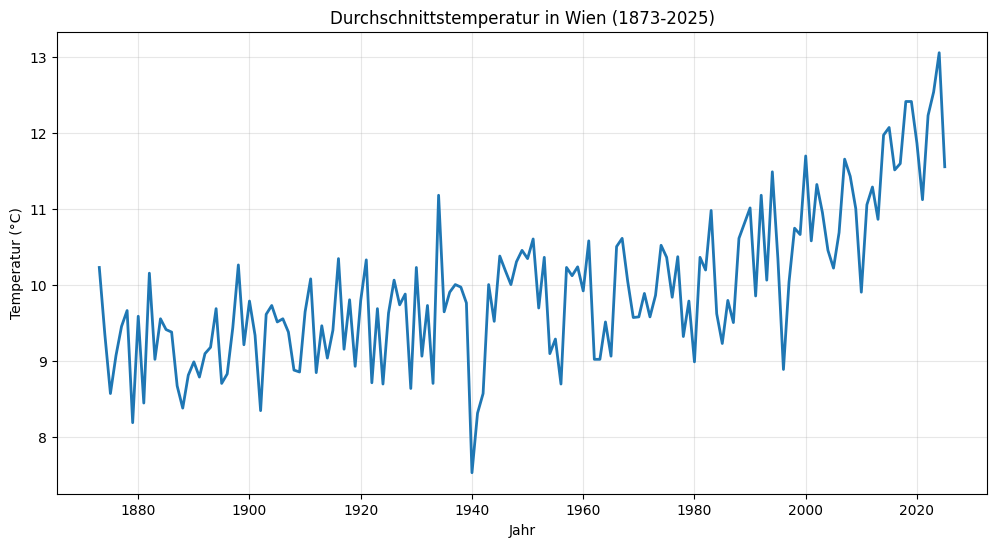

In [23]:
plt.figure(figsize=(12, 6))
yearly_temp = df.groupby('REF_YEAR')['T'].mean()
plt.plot(yearly_temp.index, yearly_temp.values, linewidth=2)
plt.title('Durchschnittstemperatur in Wien (1873-2025)')
plt.xlabel('Jahr')
plt.ylabel('Temperatur (°C)')
plt.grid(True, alpha=0.3)
plt.show()

Der folgende Plot zeigt die Temperaturverteilung in Wien nach Monat anhand von Boxplots.

<Figure size 1000x600 with 0 Axes>

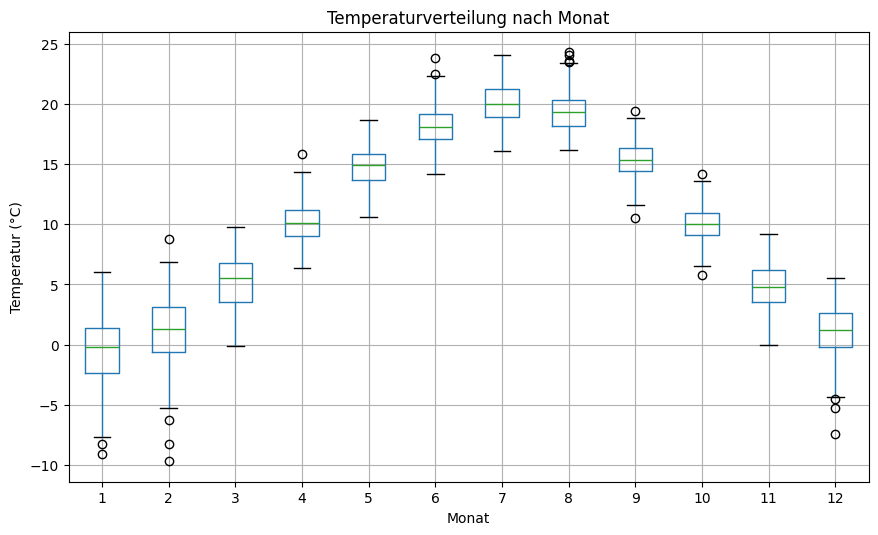

In [24]:
plt.figure(figsize=(10, 6))
df['Month'] = df['REF_DATE'].dt.month
df.boxplot(column='T', by='Month', figsize=(10, 6))
plt.title('Temperaturverteilung nach Monat')
plt.suptitle('')
plt.xlabel('Monat')
plt.ylabel('Temperatur (°C)')
plt.show()

Die folgenden zwei Boxplots zeigen die Niederschlagsverteilung in Wien nach Monat für die Zeiträume 1873-1973 und 1974-2025.

<Figure size 1000x600 with 0 Axes>

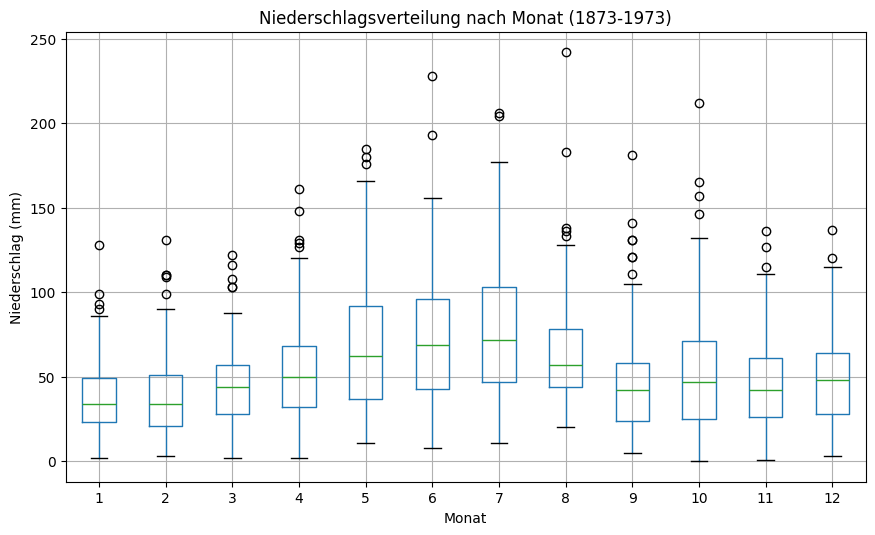

<Figure size 1000x600 with 0 Axes>

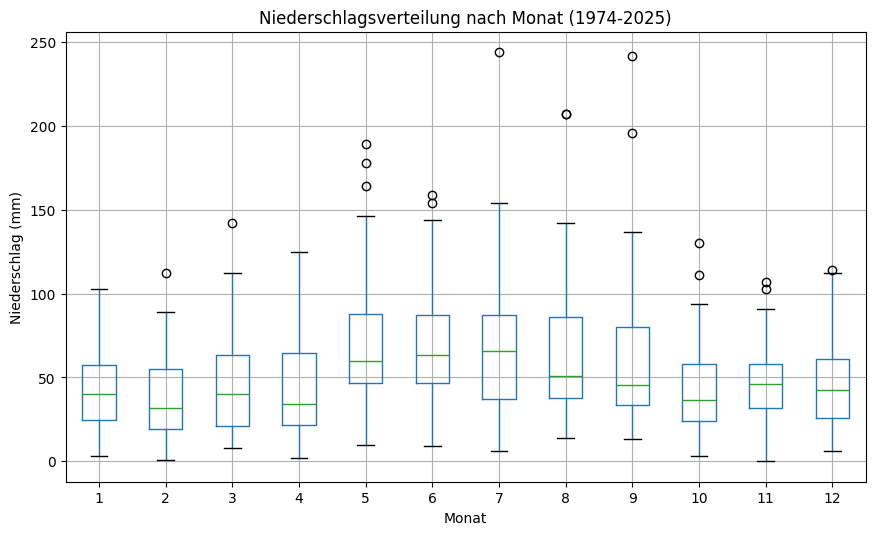

In [34]:

plt.figure(figsize=(10, 6))
df_1920_1973 = df[(df['REF_YEAR'] > 1872) & (df['REF_YEAR'] <= 1973)]
df_1920_1973.boxplot(column='PRECP_SUM', by='Month', figsize=(10, 6))
plt.title('Niederschlagsverteilung nach Monat (1873-1973)')
plt.suptitle('')
plt.xlabel('Monat')
plt.ylabel('Niederschlag (mm)')
plt.show()

plt.figure(figsize=(10, 6))
df_1974_2025 = df[(df['REF_YEAR'] >= 1974) & (df['REF_YEAR'] <= 2025)]
df_1974_2025.boxplot(column='PRECP_SUM', by='Month', figsize=(10, 6))
plt.title('Niederschlagsverteilung nach Monat (1974-2025)')
plt.suptitle('')
plt.xlabel('Monat')
plt.ylabel('Niederschlag (mm)')
plt.show()


In der folgenden Grafik wird die jährliche Niederschlagsmenge in Wien von 1873 bis 2025 dargestellt.

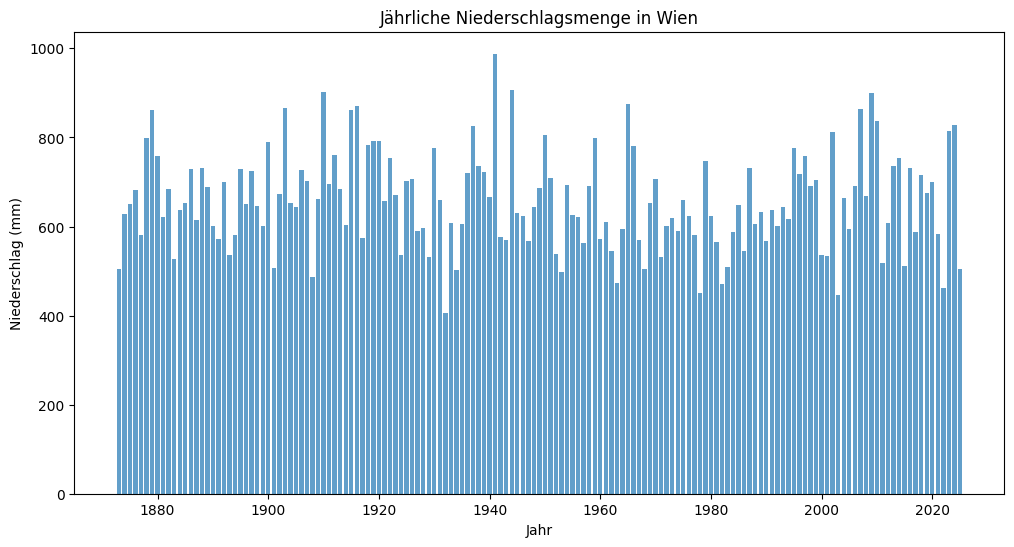

In [26]:
plt.figure(figsize=(12, 6))
yearly_rain = df.groupby('REF_YEAR')['PRECP_SUM'].sum()
plt.bar(yearly_rain.index, yearly_rain.values, alpha=0.7)
plt.title('Jährliche Niederschlagsmenge in Wien')
plt.xlabel('Jahr')
plt.ylabel('Niederschlag (mm)')
plt.show()

Die folgende Grafik untersucht den Zusammenhang zwischen Durchschnittstemperatur und Anzahl der Frosttage pro Jahr in Wien. Es ist ein negativer Zusammenhang zu erkennen, d.h. mit steigender Durchschnittstemperatur nimmt die Anzahl der Frosttage ab. Die Korrelation beträgt -0.85, was auf einen starken negativen Zusammenhang hinweist.

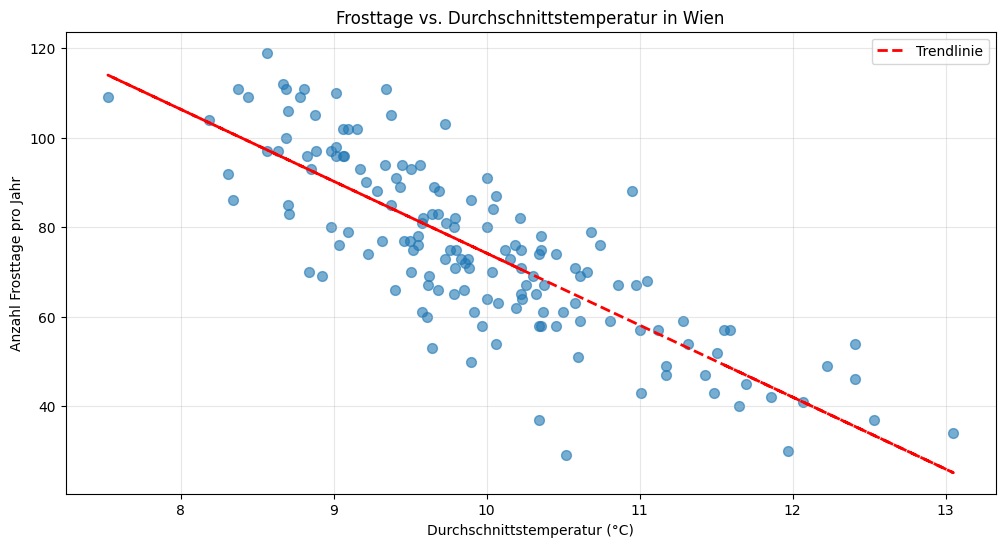

Korrelation: -0.809


In [36]:
yearly_stats = df.groupby('REF_YEAR').agg({
    'NUM_FROST': 'sum',
    'T': 'mean'
}).reset_index()

plt.figure(figsize=(12, 6))
plt.scatter(yearly_stats['T'], yearly_stats['NUM_FROST'], alpha=0.6, s=50)


z = np.polyfit(yearly_stats['T'], yearly_stats['NUM_FROST'], 1)
p = np.poly1d(z)
plt.plot(yearly_stats['T'], p(yearly_stats['T']), "r--", linewidth=2, label='Trendlinie')

plt.title('Frosttage vs. Durchschnittstemperatur in Wien')
plt.xlabel('Durchschnittstemperatur (°C)')
plt.ylabel('Anzahl Frosttage pro Jahr')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


correlation = yearly_stats['T'].corr(yearly_stats['NUM_FROST'])
print(f"Korrelation: {correlation:.3f}")

Der folgende Boxplot zeigt die Windgeschwindigkeit in Wien nach Monat.

<Figure size 1000x600 with 0 Axes>

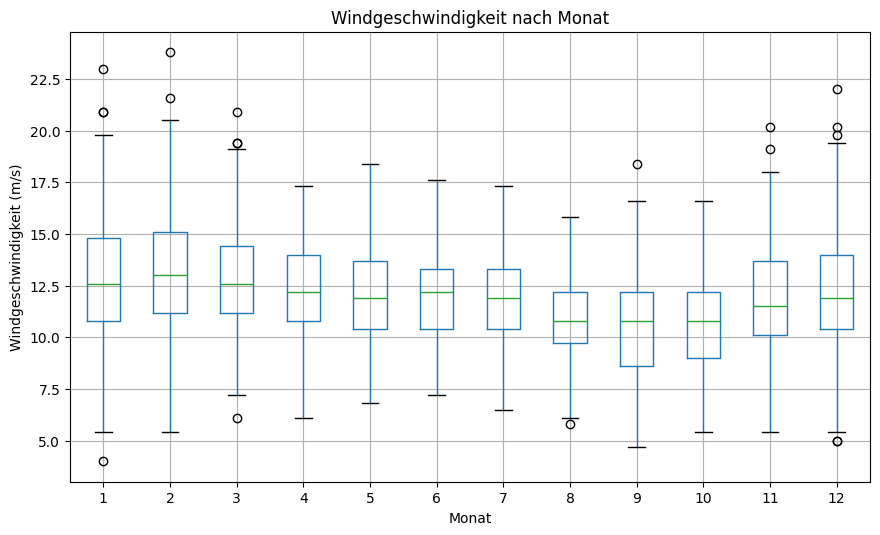

In [41]:
plt.figure(figsize=(10, 6))
df.boxplot(column='WIND_VEL', by='Month', figsize=(10, 6))
plt.title('Windgeschwindigkeit nach Monat')
plt.suptitle('')
plt.xlabel('Monat')
plt.ylabel('Windgeschwindigkeit (m/s)')
plt.show()

Max bzw. Min Temperatur über den erfassten Zeitraum

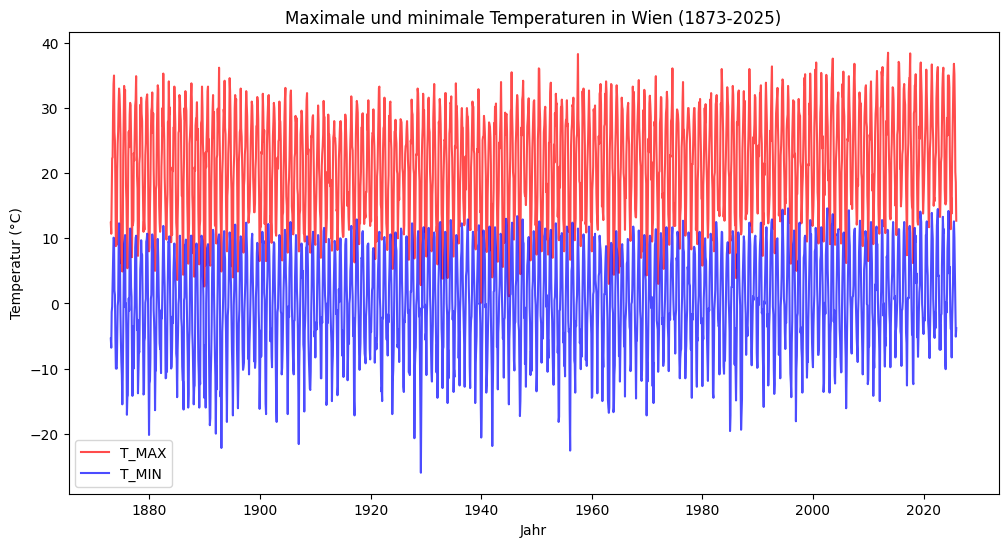

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(df['REF_DATE'], df['T_MAX'], label='T_MAX', color='red', alpha=0.7)
plt.plot(df['REF_DATE'], df['T_MIN'], label='T_MIN', color='blue', alpha=0.7)
plt.title('Maximale und minimale Temperaturen pro Monat in Wien (1873-2025)')
plt.xlabel('Jahr')
plt.ylabel('Temperatur (°C)')
plt.legend()
plt.show()


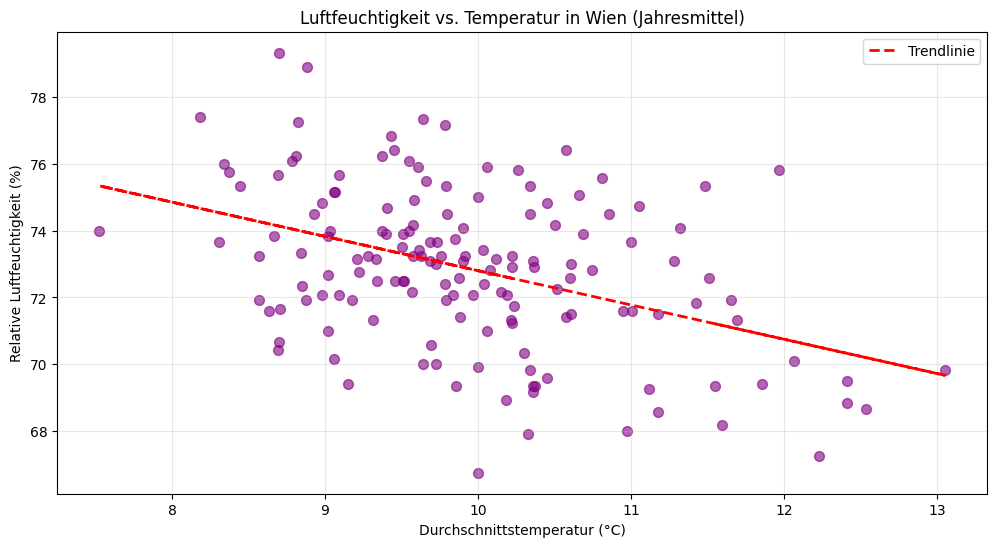

Korrelation zwischen Temperatur und Luftfeuchtigkeit: -0.422


In [47]:


yearly_humidity_temp = df.groupby('REF_YEAR').agg({
    'REL_HUM': 'mean',
    'T': 'mean'
}).reset_index()


plt.figure(figsize=(12, 6))
plt.scatter(yearly_humidity_temp['T'], yearly_humidity_temp['REL_HUM'], alpha=0.6, s=50, color='purple')


z = np.polyfit(yearly_humidity_temp['T'], yearly_humidity_temp['REL_HUM'], 1)
p = np.poly1d(z)
plt.plot(yearly_humidity_temp['T'], p(yearly_humidity_temp['T']), "r--", linewidth=2, label='Trendlinie')

plt.title('Luftfeuchtigkeit vs. Temperatur in Wien (Jahresmittel)')
plt.xlabel('Durchschnittstemperatur (°C)')
plt.ylabel('Relative Luftfeuchtigkeit (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

correlation = yearly_humidity_temp['T'].corr(yearly_humidity_temp['REL_HUM'])
print(f"Korrelation zwischen Temperatur und Luftfeuchtigkeit: {correlation:.3f}")


## Save Cleaned Data

In [49]:
df.to_csv('weather_cleaned.csv', index=False, header=True)